In [ ]:
pip install pandas scikit-learn nltk PyPDF2 sentence-transformers streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 77.4 MB/s eta 0:00:00


In [ ]:
# Imports Libraries
import pandas as pd
import numpy as np
import spacy
import re
import joblib
import PyPDF2
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Load NLP model
nlp = spacy.load("en_core_web_sm")

In [ ]:
# Load Datasets
resumes = pd.read_csv("Resumee.csv").dropna(subset=["Resume_str", "Category"])
jobs = pd.read_csv("Jobb.csv").dropna()

In [ ]:
# Helper Functions
# ------------------------------
def pdf_to_text(file_path):
    text = ""
    with open(file_path, "rb") as f:
        reader = PyPDF2.PdfReader(f)
        for page in reader.pages:
            page_text = page.extract_text()
            if page_text:
                text += page_text + "\n"
    return text

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    doc = nlp(text)
    text = ' '.join([token.lemma_ for token in doc if not token.is_stop])
    return text

# Skill Extraction
skills_db = [
    # Programming & Scripting
    "Python", "Java", "C++", "C#", "JavaScript", "MATLAB", "SQL", "HTML", "CSS", "Ruby", "Go",

    # Data & Machine Learning
    "Machine Learning", "Deep Learning", "Data Analysis", "Data Science", "TensorFlow", "PyTorch",
    "Scikit-learn", "Keras", "Pandas", "NumPy", "Matplotlib", "Seaborn", "Power BI", "Tableau","UIUX",

    # Cloud & DevOps
    "AWS", "Azure", "GCP", "Docker", "Kubernetes", "CI/CD", "Git", "Linux",

    # Other Tools & Software
    "Excel", "Word", "PowerPoint", "Jupyter Notebook", "Google Analytics", "ERP", "CRM",

    # Soft skills / business
    "Communication", "Teamwork", "Leadership", "Problem Solving", "Project Management",
    "Agile", "Scrum", "Time Management"
]

def extract_skills(text):
    text_lower = text.lower()
    found_skills = [skill for skill in skills_db if skill.lower() in text_lower]
    return found_skills

In [ ]:
# Load spaCy (lightweight)
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

In [ ]:
# Clean function (light clean)
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'\n', ' ', text)
    return text


In [ ]:
# CLEAN RESUMES
# -------------------------
resumes["clean"] = resumes["Resume_str"].apply(clean_text)
resumes = resumes[resumes["clean"].str.strip() != ""]

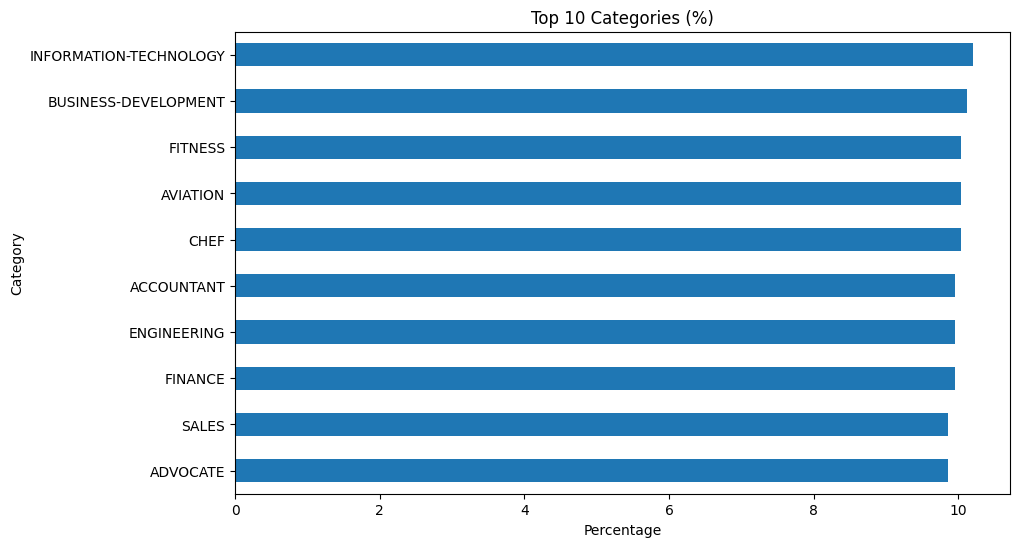

In [ ]:
# Data Visualization
# Top 10 Categories in Resumes
import matplotlib.pyplot as plt
counts = resumes["Category"].value_counts().head(10)
percent = counts / counts.sum() * 100

plt.figure(figsize=(10,6))
percent.plot(kind='barh')
plt.title("Top 10 Categories (%)")
plt.xlabel("Percentage")
plt.gca().invert_yaxis()
plt.show()

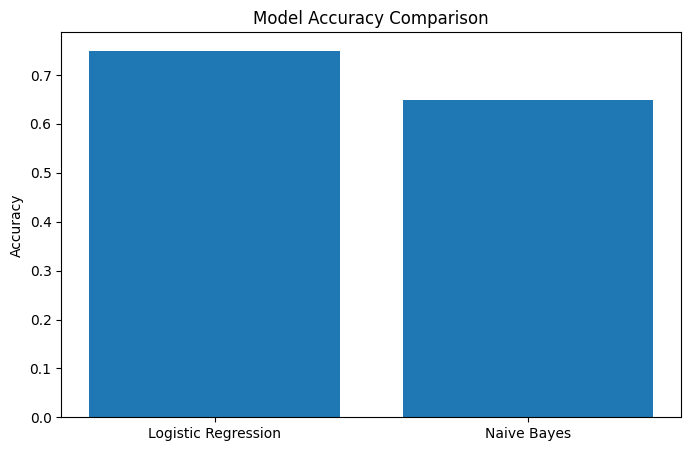

In [ ]:
models = ["Logistic Regression", "Naive Bayes"]
accuracy = [0.75, 0.65]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

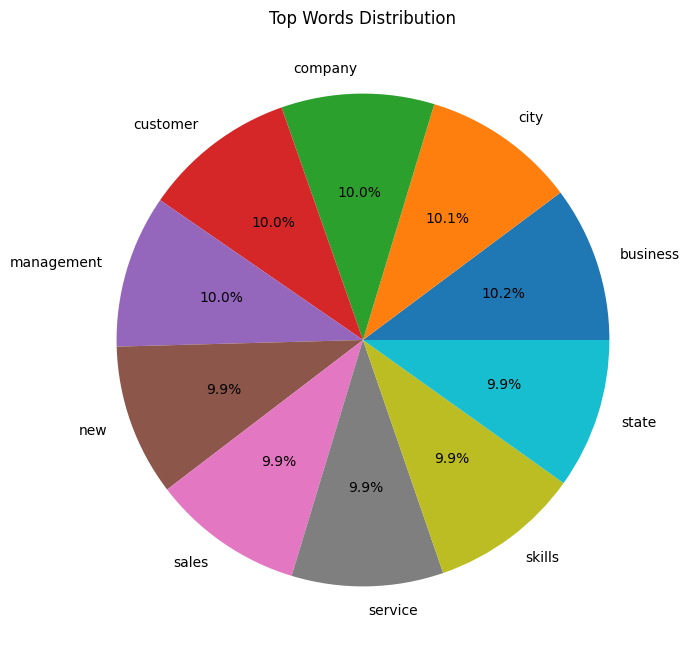

In [ ]:
# Top Words in Resumes
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.pie(counts, labels=words, autopct='%1.1f%%')
plt.title("Top Words Distribution")
plt.show()

In [ ]:
# Use Sentence Transformers for embeddings
from sentence_transformers import SentenceTransformer

model_embed = SentenceTransformer('all-MiniLM-L6-v2')

X_embed = model_embed.encode(resumes["clean"].tolist())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [40]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer('all-MiniLM-L6-v2')

X_embed = embedder.encode(resumes["clean"].tolist())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [41]:
# Train model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_embed, y)

LogisticRegression(max_iter=1000)

In [42]:
# Evaluate
y_pred = model.predict(X_embed)

In [43]:
# Evaluation
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))


===== Logistic Regression =====
Accuracy: 0.6252465483234714
F1 Score: 0.6013291692527272

===== Naive Bayes =====
Accuracy: 0.5187376725838264
F1 Score: 0.4850414801128287


In [44]:
# Process Job Dataset
# -------------------------
jobs["text"] = (
    jobs["Title"].astype(str) + " " +
    jobs["Skills"].astype(str) + " " +
    jobs["Responsibilities"].astype(str) + " " +
    jobs["Keywords"].astype(str)
)

jobs["clean"] = jobs["text"].apply(clean_text)
jobs = jobs[jobs["clean"].str.strip() != ""]

In [45]:
# Save Files
# -------------------------
joblib.dump(model, "model.pkl")
joblib.dump(tfidf, "tfidf.pkl")

jobs.to_csv("Jobb_clean.csv", index=False)

print("✅ Training + Evaluation Complete")

✅ Training + Evaluation Complete


In [ ]:
resumes = resumes[resumes["clean"].str.strip() != ""]

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
X = tfidf.fit_transform(resumes["clean"])
y = resumes["Category"]

In [ ]:
print(X.shape)
print(y.isna().sum())

(2534, 5000)
0
